### Simple Features

É um padrão internacional que define como objetos do mundo real com localização espacial devem ser representados, armazenados e manipulados em computadores e banco de dados.

A geometria espacial é representada por uma hierarquia de classes. Sendo composta pelos seguintes elementos

* **Point** (ponto) - É um par (x, y) ou (x, y, z) podendo representar a localização de uma árvore, um poste ou uma antena.
* **LineString** (linha) - É uma sequência de pontos conectados podendo representar um trecho de rio, uma rua ou uma linha de transmissão.
* **Polygon** (polígono) - É uma área fechada com um anel externo e zero ou mais anéis internos (buracos) podendo representar um lote, um município, um lago (com ilhas como buracos).
* **MultiPoint** (múltiplos pontos) - É uma coleção de pontos que pode representar várias árvores agrupadas.
* **MultiLineString** (múltiplas linhas) - É uma coleção de linhas que pode representar um sistema de drenagem com vários rios.
* **MultiPolygon** (múltiplos polígonos) - É uma coleção de polígonos que pode representar um arquipélago (onde cada ilha é um polígono)

Regras de validade para os elementos citados acima
* Polygon = O anel externo deve ser fechado (primeiro ponto = último ponto) e orientado no sentido anti-horário. Buracos (anéis internos) devem estar no sentido horário)
* LineString = Se ela tiver apenas 2 pontos iguais é inválida.
* MultiPolygon = Os polígonos internos não podem se sobrepor.

### Shapely
É uma biblioteca Python usada para analisar e manipular objetos geométricos no espaço bidimensional (2D) e que implementa o modelo Simple Features.

In [15]:
import shapely
from shapely.geometry import MultiPoint, MultiLineString, MultiPolygon, Point, LineString, Polygon
from shapely.geometry import GeometryCollection
from shapely import wkt, wkb
import matplotlib.pyplot as plt

Criando um ponto

In [9]:
ponto = Point(-47.66, -2.76)

print("Ponto:", ponto)
print("tipo:", ponto.geom_type)
print("Coordenadas:", list(ponto.coords))
print("x =", ponto.x, "| y =", ponto.y)

Ponto: POINT (-47.66 -2.76)
tipo: Point
Coordenadas: [(-47.66, -2.76)]
x = -47.66 | y = -2.76


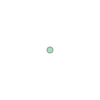

In [13]:
ponto

Criando uma linha

In [12]:
linha = LineString([(0, 0), (10, 5), (20, 0), (25, 10)])
print("Linha:", linha)
print("tipo:", linha.geom_type)
print("número de vértices", len(list(linha.coords)))
print("Coordenadas:", list(linha.coords))

Linha: LINESTRING (0 0, 10 5, 20 0, 25 10)
tipo: LineString
número de vértices 4
Coordenadas: [(0.0, 0.0), (10.0, 5.0), (20.0, 0.0), (25.0, 10.0)]


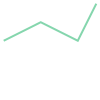

In [14]:
linha

Criando um polígono

In [16]:
poligono = Polygon([(0, 0), (10, 0), (10, 10), (0, 10), (0, 0)])
print("Polígono:", poligono)
print("tipo:", poligono.geom_type)
print("anel externo", list(poligono.exterior.coords))

Polígono: POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0))
tipo: Polygon
anel externo [(0.0, 0.0), (10.0, 0.0), (10.0, 10.0), (0.0, 10.0), (0.0, 0.0)]


In [17]:
poligono.contains(ponto)

False

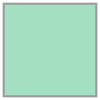

In [18]:
poligono

In [22]:
poligono_com_buraco = Polygon(
    [(0, 0), (10, 0), (10, 10), (0, 10), (0, 0)],
    holes=[[(3, 3), (7, 3), (7, 7), (3, 7), (3, 3)]]
)

print("Polígono com buraco:", poligono_com_buraco)
print("número de buracos:", len(list(poligono_com_buraco.interiors)))

Polígono com buraco: POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0), (3 3, 7 3, 7 7, 3 7, 3 3))
número de buracos: 1


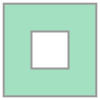

In [21]:
poligono_com_buraco

Geometrias Multi e coleções

In [23]:
multiponto = MultiPoint([(0, 0), (5, 5), (10, 0)])
print("MultiPoint:", multiponto)
print("número de pontos:", len(multiponto.geoms))

MultiPoint: MULTIPOINT ((0 0), (5 5), (10 0))
número de pontos: 3


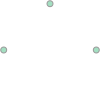

In [24]:
multiponto

In [25]:
multilinha = MultiLineString([
    [(0, 0), (5, 5), (10, 0)],
    [(0, 10), (5, 15), (10, 10)]
])

print("MultiLineString:", multilinha)
print("número de linhas:", len(multilinha.geoms))

MultiLineString: MULTILINESTRING ((0 0, 5 5, 10 0), (0 10, 5 15, 10 10))
número de linhas: 2


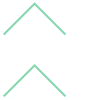

In [26]:
multilinha

In [27]:
multipoligono = MultiPolygon([
    Polygon([(0, 0), (5, 0), (5, 5), (0, 5)]),
    Polygon([(10, 10), (15, 10), (15, 15), (10, 15)])
])
print("MultiPolygon:", multipoligono)
print("número de polígonos:", len(multipoligono.geoms))

MultiPolygon: MULTIPOLYGON (((0 0, 5 0, 5 5, 0 5, 0 0)), ((10 10, 15 10, 15 15, 10 15, 10 10)))
número de polígonos: 2


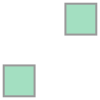

In [29]:
multipoligono

Como saber qual é o tipo de uma geometria que você recebeu?

In [30]:
isinstance(ponto, Point)
isinstance(ponto, Polygon)

False

### Propriedades das geometrias com o Shapely

In [31]:
quadrado = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

print("área:", quadrado.area)
print("perímetro:", quadrado.length)
print("centróide:", quadrado.centroid)
print("envelope (bbox):", quadrado.bounds)
print("tipo WKT:", quadrado.wkt)

área: 100.0
perímetro: 40.0
centróide: POINT (5 5)
envelope (bbox): (0.0, 0.0, 10.0, 10.0)
tipo WKT: POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0))


**O que é o bbox?**
É chamado de bounding box (ou envelope) e *é a menor caixa ou retângulo que consegue quardar uma forma geométrica inteira dentro dele*.




In [33]:
linha = LineString([(0, 0), (10, 10), (20, 0)])
print("Comprimento:", linha.length)
print("área:", linha.area)
print("Centróide:", linha.centroid)
print("Envelope:", linha.bounds)

Comprimento: 28.284271247461902
área: 0.0
Centróide: POINT (10 5)
Envelope: (0.0, 0.0, 20.0, 10.0)


In [35]:
ponto = Point(5, 5)

print("área:", ponto.area)
print("Comprimento:", ponto.length)
print("Centroide:", ponto.centroid)
print("Envelope:", ponto.bounds)

área: 0.0
Comprimento: 0.0
Centroide: POINT (5 5)
Envelope: (5.0, 5.0, 5.0, 5.0)


As propriedades mais usadas são:
* **area** = área da geometria
* **length** = comprimento/perímetro
* **centroide** = centro geométrico
* **bounds** = rentângulo envolvendo mínimo (minx, miny, maxx, maxy)
* **geom_tyoe** = tipo da geometria
* **wkt** = representação well-know text
* **is_valid** = verifica se a geometria é topologicamente válida
* **is_empty** = verifica se a geometria está vazia
* **has_z** = verifica se tem a coordenada z (3D)
* **geoms** = é uma coleção ou lista que guarda as geometrias individuais dentro de um objeto de múltiplas geometrias. ou seja é a ferramenta que permite que você veja e mexa em cada uma das das formas separadamente. (apenas para objetos do tipo multi)


ps: o wkt (well-known text) é o formato de texto padronizado pela OGC para representar geometrias. por exemplo POINT(-46.63 -23.55) é WKT. é basicamente o JSON das geometrias, que é legível por humanos e máquinas.

In [36]:
linha.wkt

'LINESTRING (0 0, 10 10, 20 0)'

**O que é a função buffer?** É uma função que executa *uma operação geométrica que cria uma nova área polgonal ao redor*, para dentro ou para fora de uma geometria (ponto, linha ou polígono) com base em uma distância específica.

* Se a distância for positiva o que ocorre é a expansão ou dilatação da geometria, criando uma zona de contorno ao redor dela.
* Se a distância for negativa o que ocorre é a contração ou o encolhimento da geometria, o que reduz a área interna.

ps: o retorno sempre vai ser uma geometria do tipo poligonal.

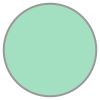

In [38]:
ponto_teste = Point(0, 0)

#criando um buffer com raio de 5 unidades ao redor do ponto
buffer_teste = ponto_teste.buffer(5)
buffer_teste

### Operações geométricas usando o Shapely

In [54]:
from shapely import affinity

ponto = Point(5, 5)
linha = LineString([(0, 0), (10, 0)])
poligono = Polygon([(2, 2), (8, 2), (8, 8), (2, 8)])

def plot_geoms(original, resultado, titulo_original="Original", titulo_resultado="Resultado"):
  """Função para comparar geometrias antes e depois"""

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

  for ax, geom, titulo in [(ax1, original, titulo_original), (ax2, resultado, titulo_resultado)]:
    #verificando se tem geométrias internas
    if hasattr(geom, "geoms"):
      for g in geom.geoms:
        #pega as coordenadas das formas geométricas no interior, verificando se é um polígono ou um ponto
        xs, ys = g.exterior.xy if hasattr(g, "exterior") else g.xy if hasattr(g, "xy") else ([g.x], [g.y])
        ax.fill(xs, ys, alpha=0.8, color="pink") if hasattr(g, "exterior") else ax.plot(xs, ys)

    #verificando se pelo menos é um polígono
    elif hasattr(geom, "exterior"):
      xs, ys = geom.exterior.xy
      ax.fill(xs, ys, alpha=0.8, facecolor="pink", edgecolor="brown")
      for interior in geom.interiors:
        ix, iy = interior.xy
        ax.fill(ix, iy, alpha=0.8, color="white")

    #verificando se pelo menos é um ponto
    elif hasattr(geom, "xy"):
      xs, xy = geom.xy
      ax.plot(xs, xy, "o-", color="pink")
    else:
      ax.plot(geom.x, geom.y, "o", color="pink")


    ax.set_title(titulo)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

Buffer ao redor de um ponto:
área do buffer: 12.546193962183755
perímetro do buffer: 12.561324627819015


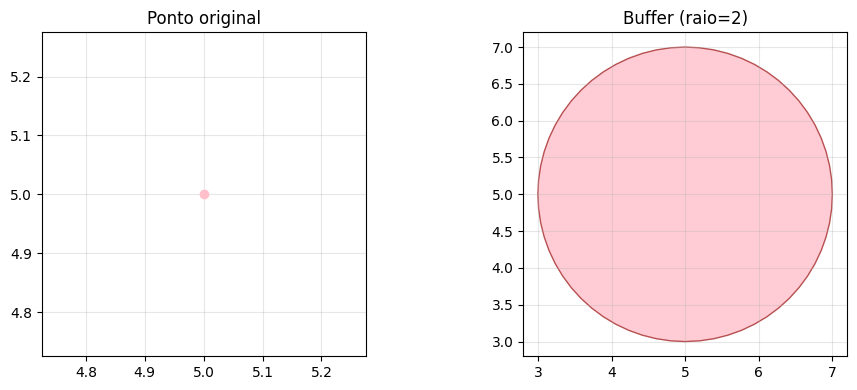

In [55]:
print("Buffer ao redor de um ponto:")
buf = ponto.buffer(2)
print("área do buffer:", buf.area)
print("perímetro do buffer:", buf.length)
plot_geoms(ponto, buf, "Ponto original", "Buffer (raio=2)")

Envelope convexo (convex hull):


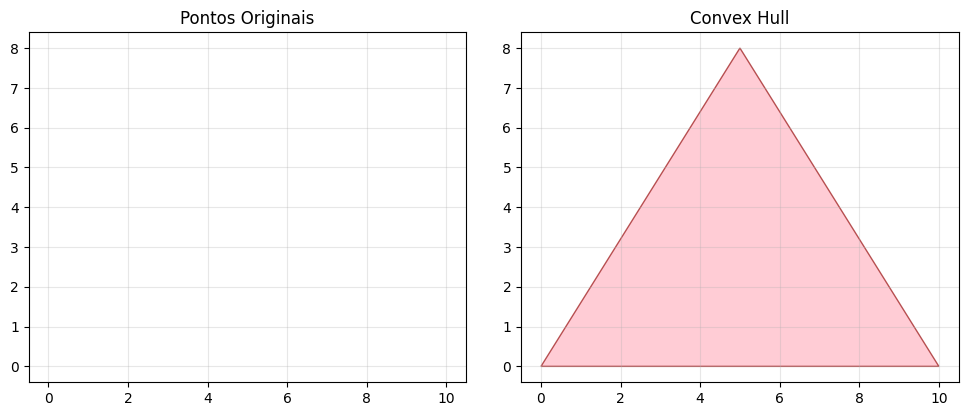

In [56]:
print("Envelope convexo (convex hull):")
pts = MultiPoint([(0, 0), (5, 1), (10, 0), (5, 8), (3, 3)])
hull = pts.convex_hull
plot_geoms(pts, hull, "Pontos Originais", "Convex Hull")

**Qual a diferença entre convex_hull e buffer?** *O convex_hull tem como objetivo gerar a menor geométria convexa que envolve completamente uma outra geométrica, enquanto o buffer usa uma distância fixa para criar uma área ao redor de um objeto usando o raio.*

**Simplificação de geometria | Simplify**

**O que é o simplify?** *É uma função que retorna uma versão simplificada da geométria de entrada usando o algoritmo douglas-peucker*.

Simplificação de geometria:
vértices antes: 11 -> depois: 2


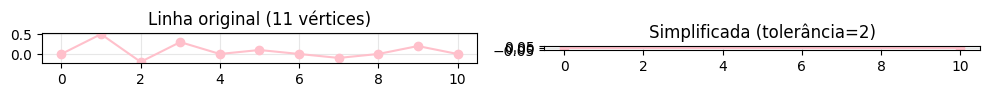

In [59]:
print("Simplificação de geometria:")
complexa = LineString([(0, 0), (1, 0.5), (2, -0.2), (3, 0.3), (4, 0), (5, 0.1), (6, 0), (7, -0.1), (8, 0), (9, 0.2), (10, 0)])
simplificada = complexa.simplify(2.0, preserve_topology=True)
print(f"vértices antes: {len(list(complexa.coords))} -> depois: {len(list(simplificada.coords))}")
plot_geoms(complexa, simplificada, "Linha original (11 vértices)", "Simplificada (tolerância=2)")

ps: 2.0 representa o valor máximo permitido para o deslocamento geométrico. quanto maior for esse número menor é o número de vértices na geométria resultante.

preserve_topology é para evitar criar geometrias inválidas, porém é importante destacar que isso é algo que tem mais custo computacional.

**Por qual razão a simplificação de geometria é usada?** *Para economizar tempo, memória e processamento do computador.*

Affinity é uma função para mover, rotacionar e escalar as geometrias.

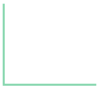

In [69]:
from shapely import affinity

line = LineString([(1, 9), (1, 2), (9, 2)])
rotated_a = affinity.rotate(line, 90)
rotated_b = affinity.rotate(line, 90, origin="centroid")
line

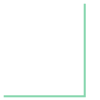

In [70]:
rotated_a

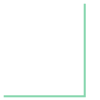

In [71]:
rotated_b

Resumo das operações possíveis:
* **buffer** = cria uma área de influência ao redor de um ponto, rio ou estrada
* **envelope** = calcula o retângulo envolvente mínimo (bbox)
* **convex_hull** = encontra o menor polígono convexo que contém um conjunto de pontos
* **simplify** = reduz o número de vértices mantendo a forma geral
* **affinity** = move, rotaciona, escala geometrias

### Relações espaciais (predicados)

Os predicados espaciais são funções que respondem perguntadas relacionadas a relações espaciais, como se o elemento A toca o elemento B, se algum elemento está dentro de outro etc. Por isso, eles retornam True ou False apenas.

Segundo o padrão OGC existem 8 predicados.

* **equals** = a e b são topologicamente iguais
* **disjoint** = a e b não têm nenhum ponto em comum
* **intersects** = a e b têm pelo menos um ponto em comum
* **touches** = a e b se tocam apenas na fronteira, sem sobrepor interiores
* **crosses** = a e b se cruzam (dimensões diferentes: linha x polígono)
* **within** = a está completamente dentro de b
* **contains** = a contém completamente b (inverso de within)
* **overlaps** = a e b se sobrepõem parcialmente (mesma dimensão)

In [101]:
from shapely.geometry import box

box_teste = box(9, 9, 19, 19)

fora = box(3, 3, 5, 5)  #caixa b
dentro = box(10, 10, 12, 12)  #caixa c
tocando = box(19, 9, 29, 19) #caixa d
intersectando = box(11, 11, 21, 21) #caixa e
cruzando = LineString([(0, 11), (21, 11)])
sobrepondo = box(11, 11, 23, 23)

print("A caixa B está dentro da primeira? ", box_teste.contains(fora))
print("A caixa C está dentro da primeira", box_teste.contains(dentro))
print("A caixa D está tocando a primeira?", box_teste.touches(tocando))
print("A caixa E tem interseção com a primeira?", box_teste.intersects(intersectando))
print("As linhas estão cruzando a caixa?", box_teste.crosses(cruzando))
print("A última caixa está sobrepondo a primeira?", box_teste.overlaps(sobrepondo))

A caixa B está dentro da primeira?  False
A caixa C está dentro da primeira True
A caixa D está tocando a primeira? True
A caixa E tem interseção com a primeira? True
As linhas estão cruzando a caixa? True
A última caixa está sobrepondo a primeira? True


In [98]:
#função para auxiliar na visualização dos predicados
def visualizar_predicado(a, b, predicado_nome, resultado):
  fig, ax = plt.subplots(figsize=(5, 5))

  xs_a, ys_a = a.exterior.xy
  ax.fill(xs_a, ys_a, alpha=0.8, color="pink", label="a")

  if hasattr(b, "exterior"):
    xs_b, ys_b = b.exterior.xy
    ax.fill(xs_b, ys_b, alpha=0.8, color="brown", label="b")
  elif hasattr(b, "xy"):
    xs_b, ys_b = b.xy
    ax.plot(xs_b, ys_b, "-", color="brown", linewidth=2, label="b")
  else:
    ax.plot(b.x, b.y, "o", color="brown", markersize=10, label="b")

  cor = "pink" if resultado else "purple"
  ax.set_title(f"{predicado_nome}: {resultado}", fontsize=14, color=cor, weight="bold")
  ax.set_aspect("equal")
  ax.legend()
  ax.grid(True, alpha=0.3)
  plt.show()

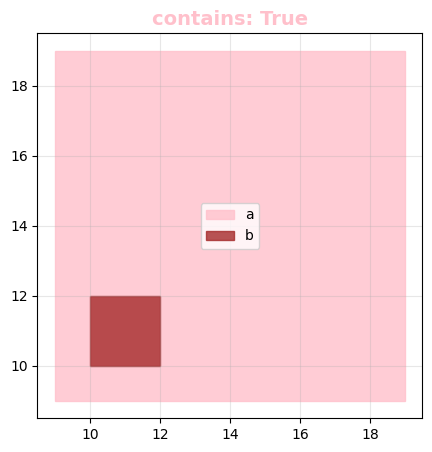

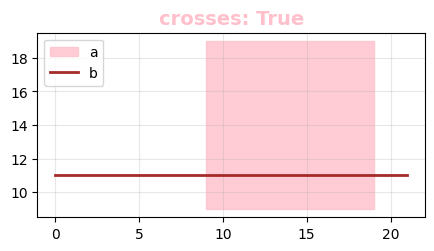

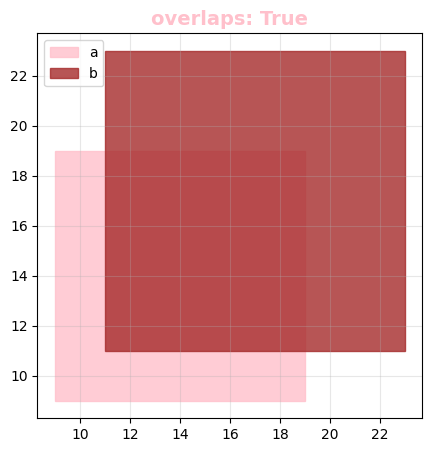

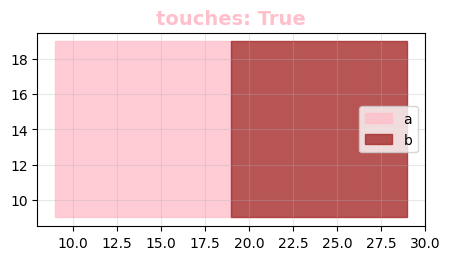

In [102]:
visualizar_predicado(box_teste, dentro, "contains", box_teste.contains(dentro))
visualizar_predicado(box_teste, cruzando, "crosses", box_teste.crosses(cruzando))
visualizar_predicado(box_teste, sobrepondo, "overlaps", box_teste.overlaps(sobrepondo))
visualizar_predicado(box_teste, tocando, "touches", box_teste.touches(tocando))

### Operações de conjunto
É possível criar novas geometrias combinando geometrias já existentes, através das seguintes operações:

* **union** = geometria com todos os pontos de a e b combinados
* **intersection** = gera uma geometria com apenas a área comum de a e b
* **difference** = gera uma geometria com a área de a que não está bem b
* **symmetric_difference** = gera uma nova geometria com a área que está em a ou em b, mas não em ambos, ou seja a operção xor


In [103]:
def plot_set_op(a, b, resultado, titulo):
  fig, ax = plt.subplots(figsize=(5, 5))
  xs_a, ys_a = a.exterior.xy
  xs_b, ys_b = b.exterior.xy
  ax.fill(xs_a, ys_a, alpha=0.8, color="pink", label="a")
  ax.fill(xs_b, ys_b, alpha=0.8, color="blue", label="b")

  #verificando se é uma coleção de geometrias
  if hasattr(resultado, "geoms"):
    for g in resultado.geoms:
      xs, ys = g.exterior.xy
      ax.fill(xs, ys, alpha=0.6, color="brown", edgecolor="black", linewidth=1.5)
  elif not resultado.is_empty:
    if hasattr(resultado, "exterior"):
      xs, ys = resultado.exterior.xy
      ax.fill(xs, ys, alpha=0.6, color="brown", edgecolor="black", linewidth=1.5)
    elif hasattr(resultado, "xy"):
      xs, ys = resultado.xy
      ax.plot(xs, ys, "-", linewidth=2, color="purple")

  ax.set_title(titulo, fontsize=14)
  ax.set_aspect("equal")
  ax.legend()
  ax.grid(True, alpha=0.2)
  ax.set_xlim(0, 10)
  ax.set_ylim(0, 8)
  plt.show()

In [104]:
box1 = box(1, 1, 5, 5)
box2 = box(3, 3, 9, 6)

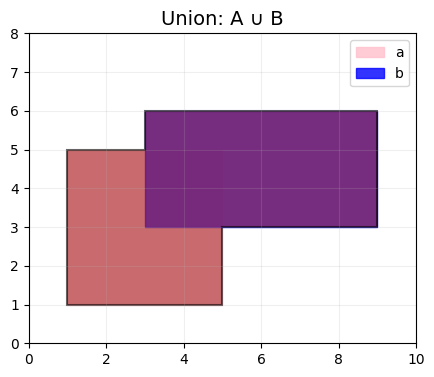

In [105]:
uniao = box1.union(box2)
intersec = box1.intersection(box2)
diferenca = box1.difference(box2)
diferenca2 = box2.difference(box1)
diferenca_simetrica = box1.symmetric_difference(box2)

plot_set_op(box1, box2, uniao, "Union: A ∪ B")

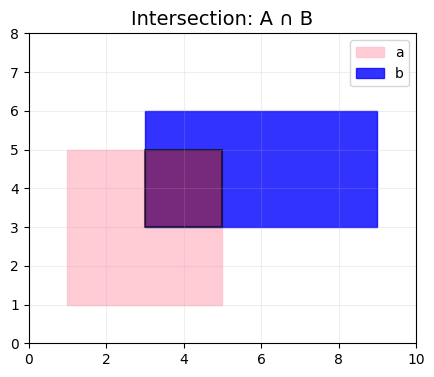

In [106]:
plot_set_op(box1, box2, intersec, "Intersection: A ∩ B")

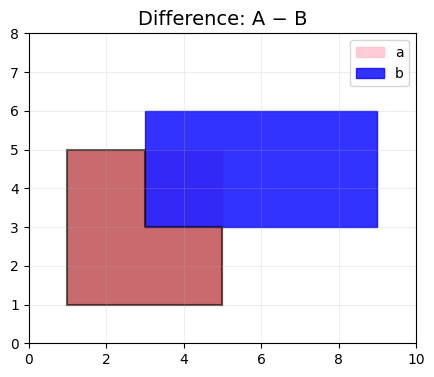

In [107]:
plot_set_op(box1, box2, diferenca, "Difference: A − B")

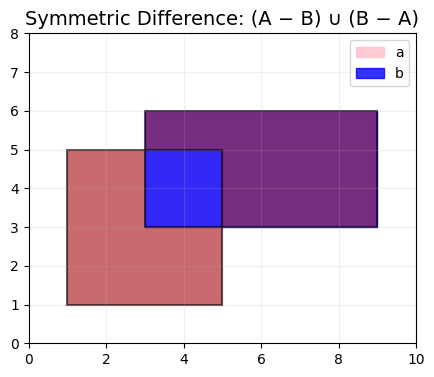

In [108]:
plot_set_op(box1, box2, diferenca_simetrica, "Symmetric Difference: (A − B) ∪ (B − A)")

### Formato WKT e WKB

Eles são formatos fundamentais para o intercâmbio de geometrias, pois representam geometrias espaciais como pontos, linhas e polígonos.

WKT ótimo para depurar, logs e configuração, enquanto o WKB é eficiente para armazenamento e transmissão (bancos de dados como PostGIS usam WKB internamente)

***WKT = Well-Known Text***

***WKB = Well-Known Binary***

In [110]:
from shapely import wkt, wkb

pol = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])

#versão textual do polígono
wkt_str = pol.wkt
print("WKT (texto):", wkt_str)

#versão binária do polígono
wkb_bytes = pol.wkb
print("WKB (binário):", wkb_bytes[:40], "...")  #primeiros 40 bytes

#lendo os arquivos e transformando eles de volta em objetos python
pol_de_wkt = wkt.loads(wkt_str)
pol_de_wkb = wkb.loads(wkb_bytes)

#verificando se a transformação deu certo
print("Ida e volta WKT", pol.equals(pol_de_wkt))
print("Ida e volta WKB", pol.equals(pol_de_wkb))

WKT (texto): POLYGON ((0 0, 10 0, 10 10, 0 10, 0 0))
WKB (binário): b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x05\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00$@\x00\x00\x00' ...
Ida e volta WKT True
Ida e volta WKB True
